# <span style="color:#0097b2">0. Data</span>
[Back to TOC](#toc)

## <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">Libraries Importation</h3>

In [1]:
import os
import sys
import warnings

import sys
sys.path.append('../')

# Suppress warnings
warnings.filterwarnings('ignore')

### Basic Libraries
import numpy as np
import pandas as pd

### Sklearn
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

In [2]:
#FUNÇOES

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import numpy as np
from PIL import Image
import urllib
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import silhouette_score, confusion_matrix
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
import umap
import math

def set_plot_properties(ax, x_label, y_label, y_lim=[]):
    """
    Set properties of a plot axis.

    Args:
        ax (matplotlib.axes.Axes): The axis object of the plot.
        x_label (str): The label for the x-axis.
        y_label (str): The label for the y-axis.
        y_lim (list, optional): The limits for the y-axis. Defaults to [].

    Returns:
        None
    """
    ax.set_xlabel(x_label)  # Set the label for the x-axis
    ax.set_ylabel(y_label)  # Set the label for the y-axis
    if len(y_lim) != 0:
        ax.set_ylim(y_lim)  # Set the limits for the y-axis if provided


def plot_inertia_and_silhouette(data, k_min=2, k_max=15):
    """
    Plot the inertia (dispersion) and silhouette score for different numbers of clusters.

    Args:
        data (numpy.ndarray or pandas.DataFrame): The input data for clustering.
        k_min (int, optional): The minimum number of clusters to evaluate. Defaults to 2.
        k_max (int, optional): The maximum number of clusters to evaluate. Defaults to 15.

    Returns:
        None
    """
    dispersions = []
    scores = []

    k_clusters = range(k_min, k_max + 1)

    for k in k_clusters:
        kmeans = KMeans(n_clusters=k, random_state=0).fit(data)
        dispersions.append(kmeans.inertia_)  # Calculate the dispersion (inertia) for each number of clusters
        kmeans.predict(data)
        scores.append(silhouette_score(data, kmeans.labels_, metric='euclidean'))  # Calculate the silhouette score

    fig, (ax1, ax2) = plt.subplots(1, 2)
    ax1.plot(k_clusters, dispersions, marker='o')  # Plot the inertia (dispersion)
    set_plot_properties(ax1, 'Number of clusters', 'Dispersion (inertia)')
    ax2.plot(k_clusters, scores, marker='o')  # Plot the silhouette score
    set_plot_properties(ax2, 'Number of clusters', 'Silhouette score')

    plt.show()


def plot_dendrogram(data, linkage_method, cut_line=None):
    """
    Plot a dendrogram for hierarchical clustering.

    Args:
        data (numpy.ndarray or pandas.DataFrame): The input data for clustering.
        linkage_method (str): The linkage method used for clustering.
        cut_line (float, optional): The threshold value to cut the dendrogram. Defaults to None.

    Returns:
        None
    """
    # Fit the AgglomerativeClustering model
    model = AgglomerativeClustering(linkage=linkage_method, distance_threshold=0, n_clusters=None).fit(data)

    # Create the plot
    fig, ax = plt.subplots()
    plt.title('Hierarchical Clustering Dendrogram')

    # Create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)

    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # Leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    # Create the linkage matrix
    linkage_matrix = np.column_stack([model.children_, model.distances_, counts]).astype(float)

    # Plot the dendrogram
    dendrogram(linkage_matrix, truncate_mode='level', p=50)

    # Add a cut line if provided
    if cut_line is not None:
        plt.axhline(y=cut_line, color='black', linestyle='-')

    # Display the plot
    plt.show()


def plot_umap_projections(people, cluster_columns, n_components=2, random_state=42):
    """
    Generates UMAP projections for multiple clustering methods and plots them in a grid.

    Parameters:
    people (DataFrame): The input data containing the features and cluster assignments.
    cluster_columns (list of str): The list of column names containing cluster assignments for each method.
    n_components (int): Number of dimensions for UMAP projection. Default is 2.
    random_state (int): Random state for UMAP. Default is 42.
    """
    # Check if at least one cluster column is provided
    if len(cluster_columns) < 1:
        raise ValueError("At least one cluster column must be provided.")

    # Determine the layout of subplots
    num_plots = len(cluster_columns)
    num_rows = math.ceil(math.sqrt(num_plots))
    num_cols = math.ceil(num_plots / num_rows)

    # Create the subplots
    fig, axs = plt.subplots(num_rows, num_cols, figsize=(16, 12))
    axs = axs.flatten()  # Flatten the array of axes

    for i, cluster_column in enumerate(cluster_columns):
        # Check if the necessary columns are present in the dataframe
        if cluster_column not in people.columns:
            raise ValueError(f"Cluster column '{cluster_column}' not found in the data.")

        # Separate features and clusters
        features = people.drop(columns=[cluster_column])
        clusters = people[cluster_column]

        # Perform UMAP
        reducer = umap.UMAP(n_components=n_components, random_state=random_state)
        umap_embedding = reducer.fit_transform(features)

        # Plot the UMAP embedding
        scatter = axs[i].scatter(
            umap_embedding[:, 0], umap_embedding[:, 1],
            c=clusters, cmap='Spectral', s=5
        )
        axs[i].set_title(f'UMAP projection of {cluster_column}')
        axs[i].set_xlabel('UMAP 1')
        axs[i].set_ylabel('UMAP 2')

        # Add a color bar to each subplot
        cbar = plt.colorbar(scatter, ax=axs[i], boundaries=np.arange(clusters.nunique() + 1) - 0.5)
        cbar.set_ticks(np.arange(clusters.nunique()))

    # Remove any unused subplots
    for j in range(i + 1, len(axs)):
        fig.delaxes(axs[j])

    # Adjust layout
    plt.tight_layout()
    plt.show()


def groupby_mean(data, variable, n_features=30):
    """
    Group the data by a variable and calculate the mean for each group.

    Args:
        data (pandas.DataFrame): The input data.
        variable (str): The variable used for grouping.
        n_features (int, optional): The number of features to include in the result. Defaults to 30.

    Returns:
        pandas.DataFrame: The transposed DataFrame containing the mean values for each group.
    """
    # Group the data by the specified variable and calculate the mean for each group
    grouped_data = data.groupby(variable).mean()

    # Select the first n_features + 1 columns (including the variable column) and transpose the DataFrame
    result = grouped_data.iloc[:, :n_features + 1].T

    # Return the transposed DataFrame
    return result

## <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">Data Importation</h3>

In [3]:
people = pd.read_csv("../data/cleaned_data/clustering_data_cleaned.csv", index_col = 'Loyalty#')

In [4]:
people.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16695 entries, 100011 to 999999
Data columns (total 56 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Income                          16695 non-null  float64
 1   Customer Lifetime Value         16695 non-null  float64
 2   EnrollmentType                  16695 non-null  int64  
 3   rejoined_program                16695 non-null  int64  
 4   Days_in_prog                    16695 non-null  float64
 5   Cancelled_program               16695 non-null  int64  
 6   Enrollment_year                 16695 non-null  int64  
 7   Enrollment_month                16695 non-null  int64  
 8   Location_cluster                16695 non-null  int64  
 9   TotalFlights                    16695 non-null  float64
 10  TotalDistance                   16695 non-null  float64
 11  TotalPointsAccumulated          16695 non-null  float64
 12  TotalPointsRedeemed            

In [5]:
people

,Income,Customer Lifetime Value,EnrollmentType,rejoined_program,Days_in_prog,Cancelled_program,Enrollment_year,Enrollment_month,Location_cluster,TotalFlights,...,Loyalty_Nova,Loyalty_Star,Education_Bachelor,Education_College,Education_Doctor,Education_High School or Below,Education_Master,Marital_Divorced,Marital_Married,Marital_Single
Loyalty#,,,,,,,,,,,,,,,,,,,,,
100011,34148.0,5780.18,0,0,0.0,0,2017,5,1,0.0,...,0,1,1,0,0,0,0,0,1,0
100012,34148.0,5780.18,0,0,0.0,0,2019,2,4,0.0,...,0,1,1,0,0,0,0,0,0,1
100013,34148.0,5780.18,0,0,0.0,0,2017,9,5,0.0,...,0,1,1,0,0,0,0,0,1,0
100014,34148.0,5780.18,0,0,0.0,0,2020,11,3,0.0,...,0,1,1,0,0,0,0,0,1,0
100015,34148.0,5780.18,0,0,0.0,0,2020,4,4,0.0,...,0,1,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,34148.0,5780.18,0,0,0.0,0,2020,3,4,0.0,...,0,1,0,1,0,0,0,0,1,0
999996,34148.0,5780.18,0,0,0.0,0,2018,9,1,0.0,...,0,1,1,0,0,0,0,0,0,1
999997,34148.0,5780.18,0,0,0.0,0,2020,1,3,0.0,...,0,1,0,1,0,0,0,0,1,0


In [6]:
people1 = people.copy()

In [7]:
for column in people1.columns:
    if column.startswith('Total_Spend_Month_'):
        people1[column] = np.sqrt(people1[column])

In [8]:
people_st_scl = StandardScaler().fit_transform(people1)
people_mm_scl = MinMaxScaler().fit_transform(people1)
people_rb_scl = RobustScaler().fit_transform(people1)

# <span style="color:#0097b2">1. Modelling</span>
[Back to TOC](#toc)

## <h2 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">Perspective 3: VALUE-BASED SEGMENTATION</h2>

Prepare the data

In [9]:
# Perspective 2 — BEHAVIORAL
engagement_features = [
    "Days_in_prog",
    "RecencyInMonths",
    "Flights_per_day",
    "PctFlightsWithCompanions",
    "PctPointsSpent"
]

In [10]:
# Prepare data
customer_engagement = people[engagement_features].copy()

In [11]:
# Apply sqrt transformation on spend/value columns
for column in customer_engagement.columns:
    if 'spend' in column.lower() or 'value' in column.lower() or 'distance' in column.lower():
        customer_engagement[column] = np.sqrt(customer_engagement[column])

In [12]:
# Scaling
customer_engagement_st = StandardScaler().fit_transform(customer_engagement)
customer_engagement_rb = RobustScaler().fit_transform(customer_engagement)
customer_engagement_mm = MinMaxScaler().fit_transform(customer_engagement)

## <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">Standard Scaling</h3>

### K-Means

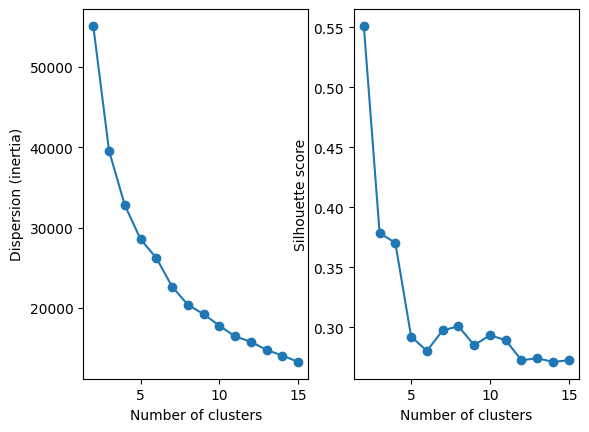

In [13]:
plot_inertia_and_silhouette(customer_engagement_st)

In [14]:
kmeans_st_scl = KMeans(n_clusters=10, random_state=42).fit(customer_engagement_st)
people['st_scaled_km_cluster10'] = kmeans_st_scl.predict(customer_engagement_st)

In [15]:
groupby_mean(people, 'st_scaled_km_cluster10')

st_scaled_km_cluster10,0,1,2,3,4,5,6,7,8,9
Income,38078.708498,37933.992749,37908.493948,38656.116907,37618.338353,37488.745073,36939.356902,38926.150538,36531.913580,37351.569463
Customer Lifetime Value,7875.859368,8329.786427,8003.783446,7824.832864,7974.343691,8098.203783,7987.594545,7738.620161,7149.506790,7652.331533
EnrollmentType,0.166008,0.027686,0.079320,0.016302,0.015395,0.158296,0.017957,0.075269,0.061728,0.155963
rejoined_program,0.018775,0.014502,0.000000,0.000000,0.000000,0.046408,0.000000,0.102151,0.074074,0.036042
Days_in_prog,397.024704,582.224786,852.219676,1863.665114,1928.628849,299.945963,1543.326599,221.564516,187.753086,386.605505
Cancelled_program,0.179842,0.615689,0.030646,0.025151,0.019411,0.208519,0.026375,0.204301,0.185185,0.176278
Enrollment_year,2020.246047,2017.800264,2019.167396,2016.365161,2016.187751,2020.420852,2017.255331,2020.473118,2020.654321,2020.263434
Enrollment_month,6.534585,7.259064,6.251095,6.672101,6.738286,7.007629,6.547699,7.973118,7.530864,6.644823
Location_cluster,2.438735,2.469347,2.434973,2.419190,2.475904,2.450095,2.423120,2.365591,2.308642,2.420052
TotalFlights,81.941601,0.000000,197.028329,175.455380,208.980254,56.080356,196.255163,18.266667,25.035802,73.399017


### Hierarchichal - Ward

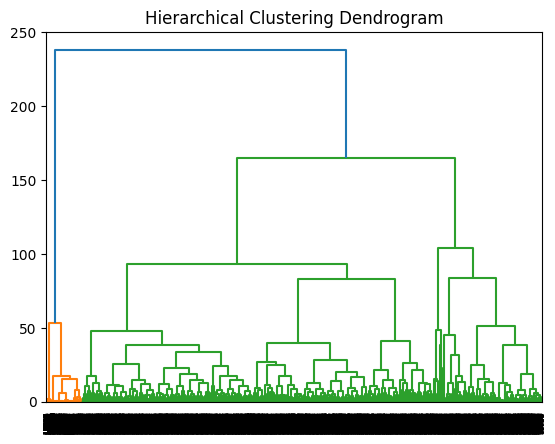

In [16]:
plot_dendrogram(customer_engagement_st, 'ward')

In [17]:
people['st_scaled_ward_cluster7'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 7
    ).fit_predict(customer_engagement_st)

In [18]:
groupby_mean(people, 'st_scaled_ward_cluster7')

st_scaled_ward_cluster7,0,1,2,3,4,5,6
Income,37933.992749,38141.740385,37523.728953,37878.466326,37708.412792,36943.286391,38070.405236
Customer Lifetime Value,8329.786427,8153.869615,7931.013105,7853.453646,7893.811023,7752.889207,8042.139445
EnrollmentType,0.027686,0.121795,0.174127,0.041338,0.015856,0.164497,0.082723
rejoined_program,0.014502,0.060897,0.042710,0.000000,0.000000,0.056805,0.000262
Days_in_prog,582.224786,221.224359,312.185626,1329.469577,1835.492785,288.487574,812.946859
Cancelled_program,0.615689,0.195513,0.199589,0.042267,0.024586,0.204734,0.042147
Enrollment_year,2017.800264,2020.647436,2020.425462,2017.825360,2016.441475,2020.467456,2019.256021
Enrollment_month,7.259064,7.000000,6.839014,6.522062,6.679316,7.066272,6.263874
Location_cluster,2.469347,2.407051,2.460780,2.441709,2.450027,2.404734,2.414398
TotalFlights,0.000000,38.513462,57.171581,178.037715,196.096954,47.806391,190.801649


## <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">MinMax Scaling</h3>

### K-Means

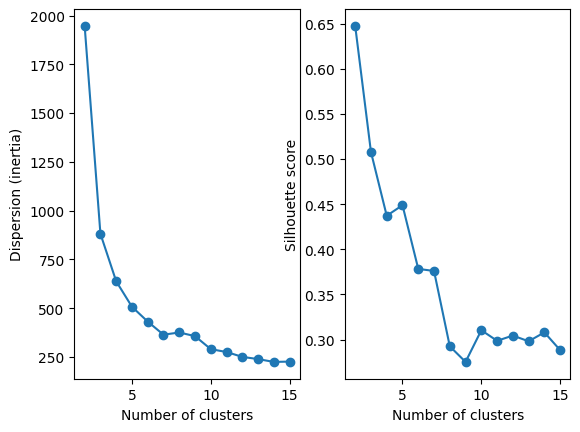

In [19]:
plot_inertia_and_silhouette(customer_engagement_mm)

In [38]:
kmeans_mm_scl = KMeans(n_clusters=3, random_state=42).fit(customer_engagement_mm)
people['mm_scaled_km_cluster3'] = kmeans_mm_scl.predict(customer_engagement_mm)

In [39]:
groupby_mean(people, 'mm_scaled_km_cluster3')

mm_scaled_km_cluster3,0,1,2
Income,37621.776070,37933.992749,37899.786356
Customer Lifetime Value,7929.031057,8329.786427,7928.740453
EnrollmentType,0.127791,0.027686,0.016129
rejoined_program,0.022590,0.014502,0.000000
Days_in_prog,515.498687,582.224786,1773.980037
Cancelled_program,0.119385,0.615689,0.026573
Enrollment_year,2019.980956,2017.800264,2016.599683
Enrollment_month,6.443000,7.259064,6.770492
Location_cluster,2.431311,2.469347,2.445135
TotalFlights,120.421434,0.000000,196.669262


### Hierarchichal - Ward

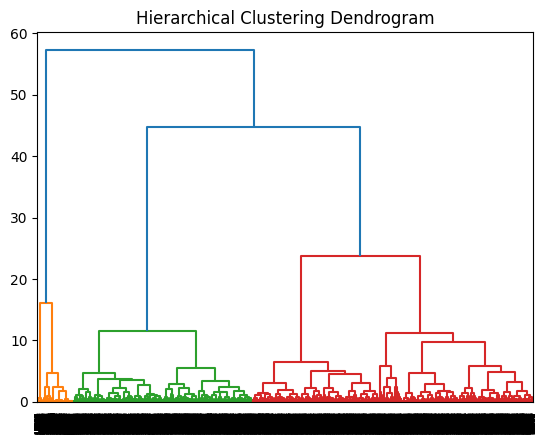

In [22]:
plot_dendrogram(customer_engagement_mm, 'ward')

In [23]:
people['mm_scaled_ward_cluster8'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 8
    ).fit_predict(customer_engagement_mm)

In [24]:
groupby_mean(people, 'mm_scaled_ward_cluster8')

mm_scaled_ward_cluster8,0,1,2,3,4,5,6,7
Income,37351.095068,38110.250304,38033.374474,38659.095705,39497.013514,37666.046332,37262.661126,37480.930980
Customer Lifetime Value,7952.207999,7935.852738,7664.995975,7881.007298,9063.696306,8203.973305,7967.366689,7982.225279
EnrollmentType,0.016679,0.180933,0.110799,0.013527,0.018018,0.029344,0.018657,0.213383
rejoined_program,0.000000,0.001217,0.099579,0.000000,0.000000,0.016988,0.000000,0.051633
Days_in_prog,1031.588039,440.822718,190.677419,2176.791343,2323.783784,283.671815,1658.859227,244.545311
Cancelled_program,0.043126,0.090872,0.204769,0.003720,0.000000,0.721236,0.043080,0.221812
Enrollment_year,2018.640457,2020.227181,2020.692847,2015.524856,2015.031532,2018.274903,2016.902985,2020.605901
Enrollment_month,6.488921,6.286004,7.319776,6.657423,7.815315,7.163707,6.748982,6.711802
Location_cluster,2.415058,2.471805,2.309958,2.473115,2.450450,2.472587,2.408752,2.485248
TotalFlights,195.194758,130.448357,27.438990,195.389144,0.000000,0.000000,196.620014,45.701791


## <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">Robust Scaling</h3>

### K-Means

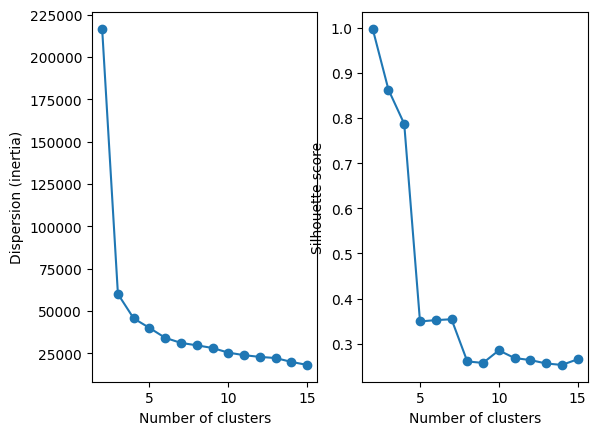

In [25]:
plot_inertia_and_silhouette(customer_engagement_rb)

In [26]:
kmeans_rb_scl = KMeans(n_clusters=3, random_state=42).fit(customer_engagement_rb)
people['rb_scaled_km_cluster3'] = kmeans_rb_scl.predict(customer_engagement_rb)

In [27]:
groupby_mean(people, 'rb_scaled_km_cluster3')

rb_scaled_km_cluster3,0,1,2
Income,36874.705882,37933.992749,37806.230561
Customer Lifetime Value,7688.976765,8329.786427,7941.322290
EnrollmentType,0.010695,0.027686,0.075329
rejoined_program,0.002674,0.014502,0.011781
Days_in_prog,649.274064,582.224786,1168.242204
Cancelled_program,0.915775,0.615689,0.029453
Enrollment_year,2018.568182,2017.800264,2018.281774
Enrollment_month,6.475936,7.259064,6.612959
Location_cluster,2.340909,2.469347,2.443243
TotalFlights,81.697594,0.000000,162.396764


### Hierarchichal - Ward

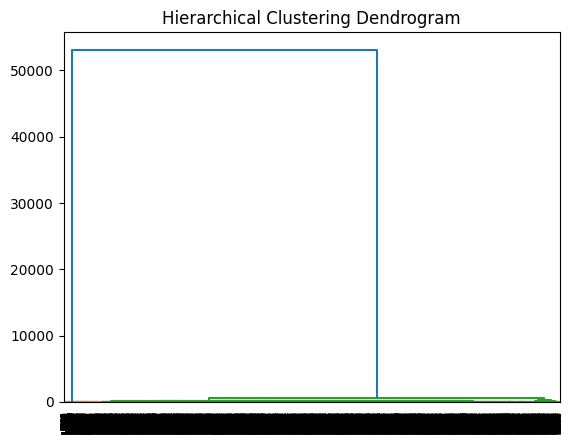

In [28]:
plot_dendrogram(customer_engagement_rb, 'ward')

In [29]:
people['rb_scaled_ward_cluster6'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 6
    ).fit_predict(customer_engagement_rb)

In [30]:
groupby_mean(people, 'rb_scaled_ward_cluster6')

rb_scaled_ward_cluster6,0,1,2,3,4,5
Income,37698.986395,38119.912038,36123.782456,37933.992749,36400.591584,39189.744186
Customer Lifetime Value,7956.439141,7908.181151,7829.498912,8329.786427,7565.992525,7757.905163
EnrollmentType,0.079916,0.064576,0.014035,0.027686,0.017327,0.004651
rejoined_program,0.014937,0.003455,0.007018,0.014502,0.000000,0.000000
Days_in_prog,1122.628580,1308.295775,664.435088,582.224786,744.940594,604.679070
Cancelled_program,0.007706,0.058995,0.912281,0.615689,0.868812,0.911628
Enrollment_year,2018.409666,2017.909912,2018.536842,2017.800264,2018.794554,2018.232558
Enrollment_month,6.672534,6.399150,6.256140,7.259064,6.960396,6.786047
Location_cluster,2.444582,2.443263,2.298246,2.469347,2.311881,2.460465
TotalFlights,158.674265,174.600213,94.022807,0.000000,111.913119,35.534419


# <span style="color:#0097b2">1. Filtering</span>
[Back to TOC](#toc)

### <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">(1) First-Examination</h3>

#### Cluster Visualization 1

In [40]:
clusters_km = ['st_scaled_km_cluster10', 'mm_scaled_km_cluster3', 'rb_scaled_km_cluster3']

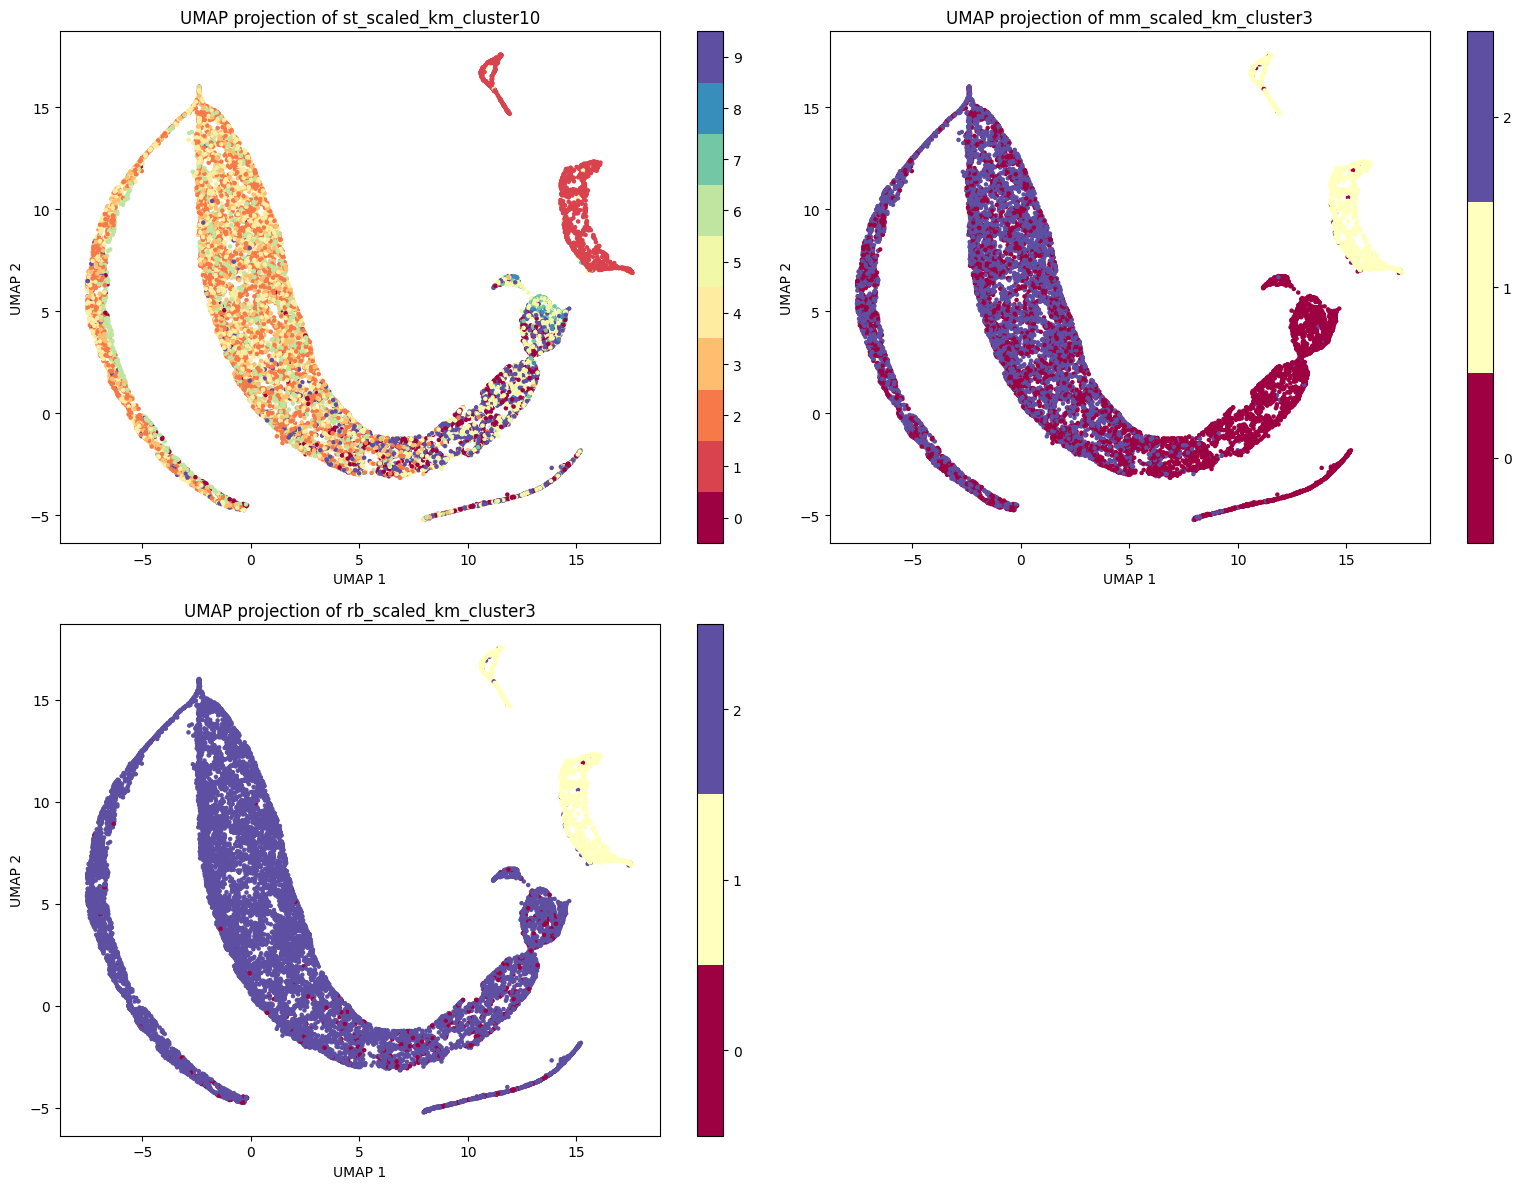

In [41]:
plot_umap_projections(people, clusters_km)

In [33]:
cluster_ward = ['st_scaled_ward_cluster7', 'mm_scaled_ward_cluster8', 'rb_scaled_ward_cluster6']

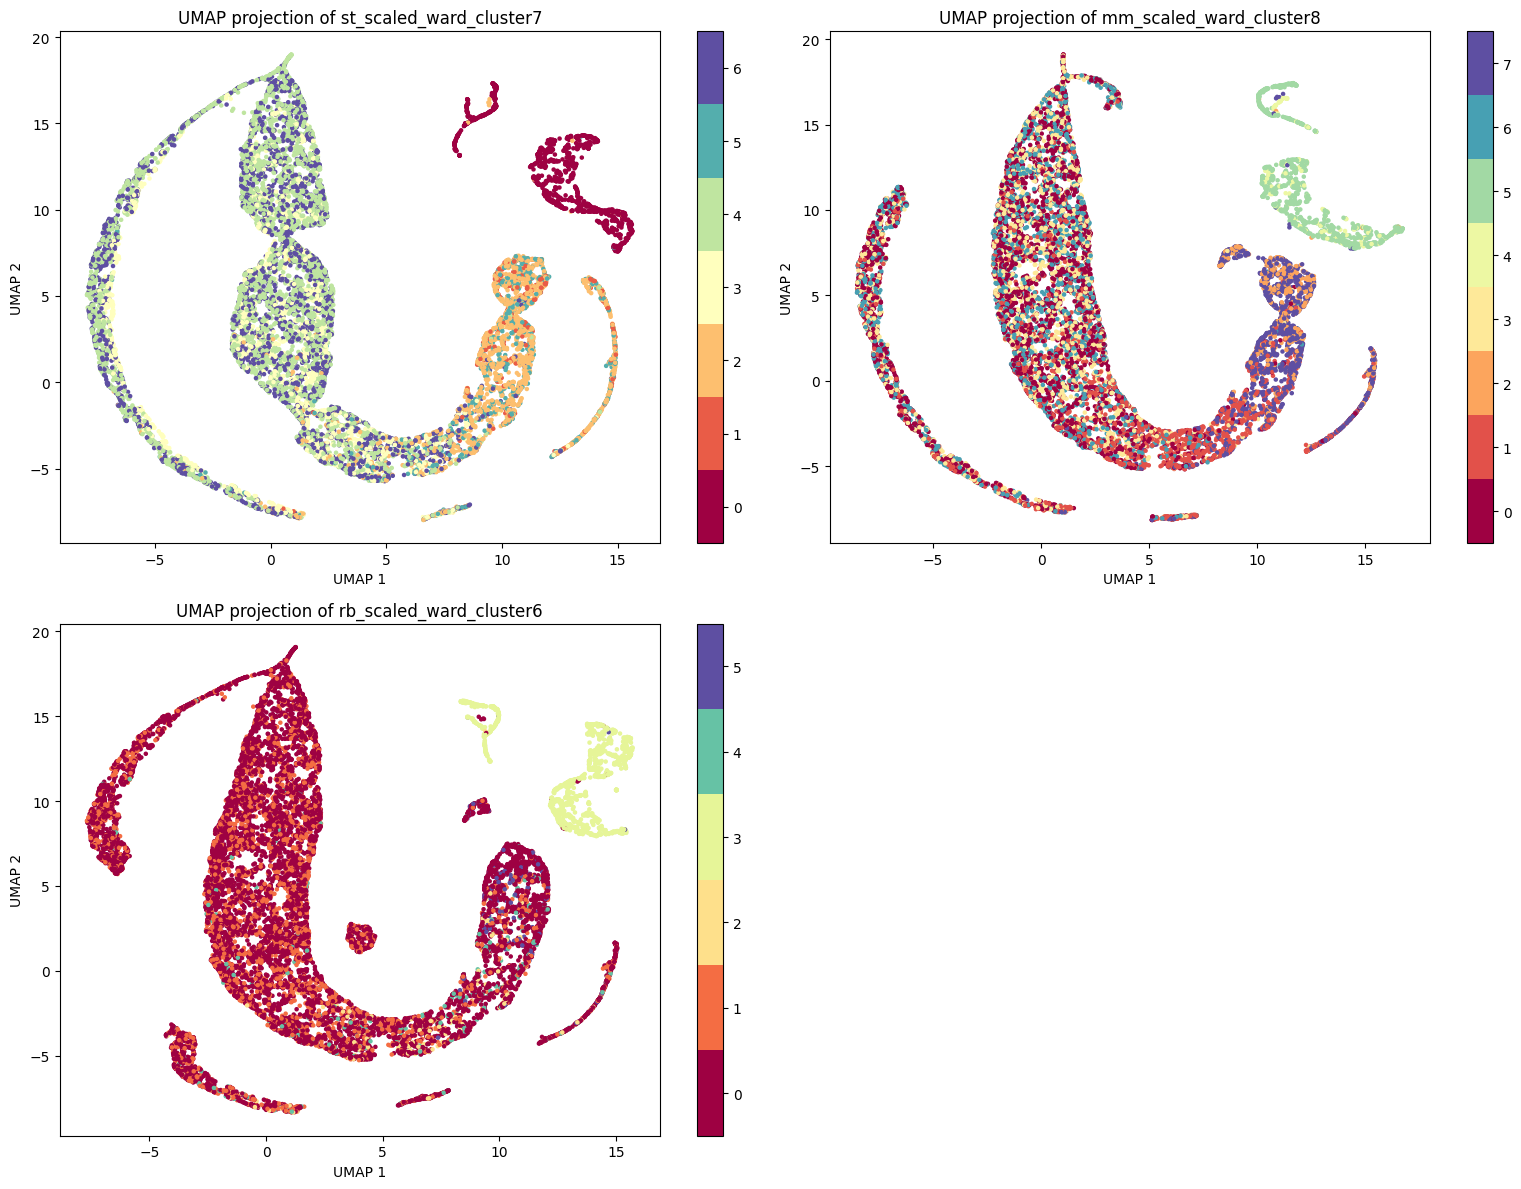

In [68]:
plot_umap_projections(people, cluster_ward)

In [42]:
groupby_mean(people, 'rb_scaled_ward_cluster6')

rb_scaled_ward_cluster6,0,1,2,3,4,5
Income,37698.986395,38119.912038,36123.782456,37933.992749,36400.591584,39189.744186
Customer Lifetime Value,7956.439141,7908.181151,7829.498912,8329.786427,7565.992525,7757.905163
EnrollmentType,0.079916,0.064576,0.014035,0.027686,0.017327,0.004651
rejoined_program,0.014937,0.003455,0.007018,0.014502,0.000000,0.000000
Days_in_prog,1122.628580,1308.295775,664.435088,582.224786,744.940594,604.679070
Cancelled_program,0.007706,0.058995,0.912281,0.615689,0.868812,0.911628
Enrollment_year,2018.409666,2017.909912,2018.536842,2017.800264,2018.794554,2018.232558
Enrollment_month,6.672534,6.399150,6.256140,7.259064,6.960396,6.786047
Location_cluster,2.444582,2.443263,2.298246,2.469347,2.311881,2.460465
TotalFlights,158.674265,174.600213,94.022807,0.000000,111.913119,35.534419


3 (people that don´t travel much)

#### Cluster Extraction 1

In [43]:
# Filter the DataFrame based on cluster labels
non_travelers = people[people['rb_scaled_ward_cluster6'] == 3]

In [44]:
# List of cluster labels to exclude
exclude_clusters = [3]

# Filter the original dataset to exclude rows with specified cluster labels
people_filtered1 = people[~people['rb_scaled_ward_cluster6'].isin(exclude_clusters)]

In [45]:
people_filtered1

,Income,Customer Lifetime Value,EnrollmentType,rejoined_program,Days_in_prog,Cancelled_program,Enrollment_year,Enrollment_month,Location_cluster,TotalFlights,...,Marital_Married,Marital_Single,st_scaled_km_cluster10,st_scaled_ward_cluster7,mm_scaled_km_cluster6,mm_scaled_ward_cluster8,rb_scaled_km_cluster3,rb_scaled_ward_cluster6,mm_scaled_km_cluster4,mm_scaled_km_cluster3
Loyalty#,,,,,,,,,,,,,,,,,,,,,
100018,82877.0,7919.20,0,0,874.0,0,2019,8,5,229.9,...,1,0,2,6,0,0,2,0,3,0
100102,0.0,2887.74,0,0,2122.0,0,2016,3,1,247.7,...,0,1,6,4,2,3,2,0,2,2
100140,0.0,2838.07,0,0,884.0,0,2019,7,5,216.8,...,0,0,2,6,0,0,2,1,3,0
100214,42837.0,4170.57,0,0,1242.0,0,2018,8,2,112.3,...,1,0,2,6,3,0,2,0,3,2
100272,80979.0,6622.05,0,0,1816.0,0,2017,1,1,186.4,...,0,0,3,4,2,6,2,1,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999891,59732.0,3745.37,0,0,245.0,1,2019,5,3,1.9,...,1,0,7,1,5,2,0,5,0,0
999902,0.0,7290.07,0,0,1681.0,0,2017,5,1,267.1,...,1,0,4,4,3,6,2,1,2,2
999940,21542.0,20266.50,0,0,523.0,0,2020,7,4,87.5,...,1,0,9,6,4,1,2,0,0,0


In [46]:
people_filtered1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15178 entries, 100018 to 999986
Data columns (total 64 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Income                          15178 non-null  float64
 1   Customer Lifetime Value         15178 non-null  float64
 2   EnrollmentType                  15178 non-null  int64  
 3   rejoined_program                15178 non-null  int64  
 4   Days_in_prog                    15178 non-null  float64
 5   Cancelled_program               15178 non-null  int64  
 6   Enrollment_year                 15178 non-null  int64  
 7   Enrollment_month                15178 non-null  int64  
 8   Location_cluster                15178 non-null  int64  
 9   TotalFlights                    15178 non-null  float64
 10  TotalDistance                   15178 non-null  float64
 11  TotalPointsAccumulated          15178 non-null  float64
 12  TotalPointsRedeemed            

In [47]:
people_filtered1 = people_filtered1.loc[:, ~people_filtered1.columns.str.startswith(("st_", "mm_", "rb_"))]

In [48]:
people_filtered1

,Income,Customer Lifetime Value,EnrollmentType,rejoined_program,Days_in_prog,Cancelled_program,Enrollment_year,Enrollment_month,Location_cluster,TotalFlights,...,Loyalty_Nova,Loyalty_Star,Education_Bachelor,Education_College,Education_Doctor,Education_High School or Below,Education_Master,Marital_Divorced,Marital_Married,Marital_Single
Loyalty#,,,,,,,,,,,,,,,,,,,,,
100018,82877.0,7919.20,0,0,874.0,0,2019,8,5,229.9,...,0,0,1,0,0,0,0,0,1,0
100102,0.0,2887.74,0,0,2122.0,0,2016,3,1,247.7,...,1,0,0,1,0,0,0,0,0,1
100140,0.0,2838.07,0,0,884.0,0,2019,7,5,216.8,...,1,0,0,1,0,0,0,1,0,0
100214,42837.0,4170.57,0,0,1242.0,0,2018,8,2,112.3,...,0,1,1,0,0,0,0,0,1,0
100272,80979.0,6622.05,0,0,1816.0,0,2017,1,1,186.4,...,0,1,1,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999891,59732.0,3745.37,0,0,245.0,1,2019,5,3,1.9,...,1,0,1,0,0,0,0,0,1,0
999902,0.0,7290.07,0,0,1681.0,0,2017,5,1,267.1,...,0,0,0,1,0,0,0,0,1,0
999940,21542.0,20266.50,0,0,523.0,0,2020,7,4,87.5,...,1,0,1,0,0,0,0,0,1,0


### <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">(2) Second-Examination</h3>

#### Re-Scaling Data 2

In [49]:
people_filtered1

,Income,Customer Lifetime Value,EnrollmentType,rejoined_program,Days_in_prog,Cancelled_program,Enrollment_year,Enrollment_month,Location_cluster,TotalFlights,...,Loyalty_Nova,Loyalty_Star,Education_Bachelor,Education_College,Education_Doctor,Education_High School or Below,Education_Master,Marital_Divorced,Marital_Married,Marital_Single
Loyalty#,,,,,,,,,,,,,,,,,,,,,
100018,82877.0,7919.20,0,0,874.0,0,2019,8,5,229.9,...,0,0,1,0,0,0,0,0,1,0
100102,0.0,2887.74,0,0,2122.0,0,2016,3,1,247.7,...,1,0,0,1,0,0,0,0,0,1
100140,0.0,2838.07,0,0,884.0,0,2019,7,5,216.8,...,1,0,0,1,0,0,0,1,0,0
100214,42837.0,4170.57,0,0,1242.0,0,2018,8,2,112.3,...,0,1,1,0,0,0,0,0,1,0
100272,80979.0,6622.05,0,0,1816.0,0,2017,1,1,186.4,...,0,1,1,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999891,59732.0,3745.37,0,0,245.0,1,2019,5,3,1.9,...,1,0,1,0,0,0,0,0,1,0
999902,0.0,7290.07,0,0,1681.0,0,2017,5,1,267.1,...,0,0,0,1,0,0,0,0,1,0
999940,21542.0,20266.50,0,0,523.0,0,2020,7,4,87.5,...,1,0,1,0,0,0,0,0,1,0


In [50]:
people_filtered11 = people_filtered1.copy()

for column in people_filtered11.columns:
    if column.startswith('Total_Spend_Month_'):
        people_filtered11[column] = np.sqrt(people_filtered11[column])

In [51]:
people_filtered1_st_scl = StandardScaler().fit_transform(people_filtered11)
people_filtered1_rb_scl = RobustScaler().fit_transform(people_filtered11)

#### Cluster Modelling 2

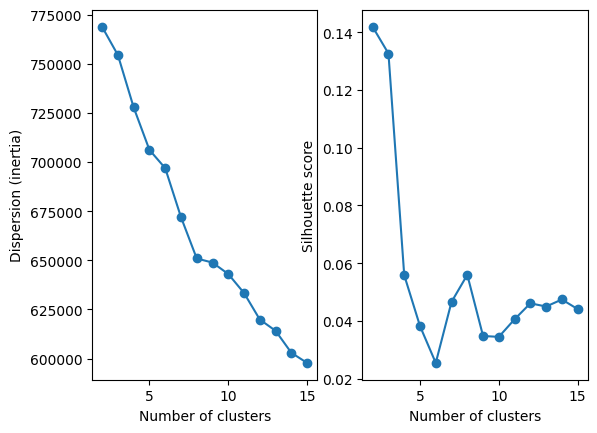

In [52]:
plot_inertia_and_silhouette(people_filtered1_st_scl)

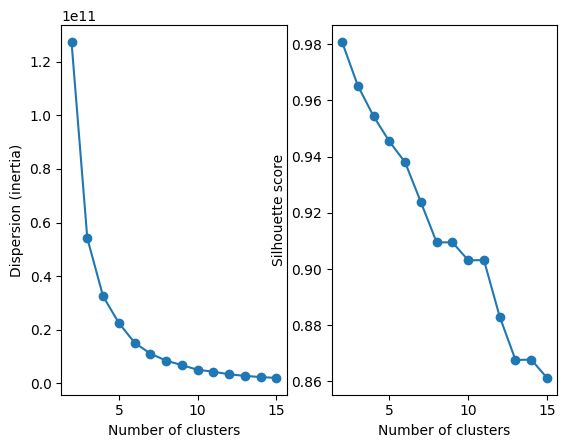

In [53]:
plot_inertia_and_silhouette(people_filtered1_rb_scl)

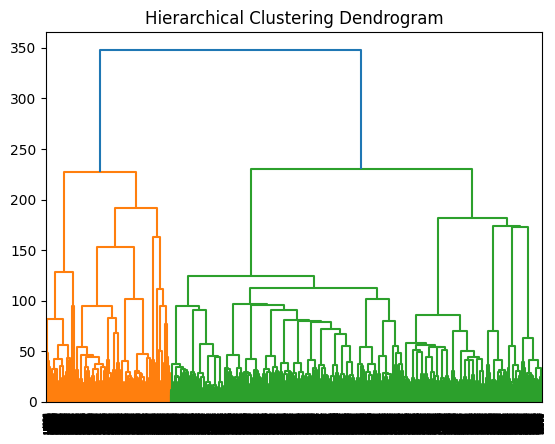

In [54]:
plot_dendrogram(people_filtered1_st_scl, 'ward')

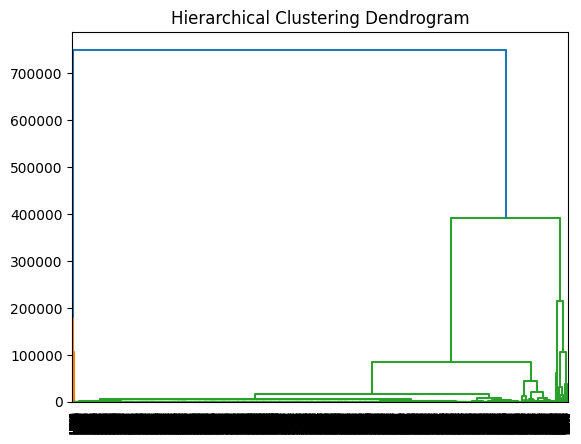

In [55]:
plot_dendrogram(people_filtered1_rb_scl, 'ward')

#### Cluster Visualization 2

In [56]:
people_filtered1['filter1_rb_scaled_ward_cluster3'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 3
    ).fit_predict(people_filtered1_rb_scl)

people_filtered1['filter1_st_scaled_ward_cluster4'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 4
    ).fit_predict(people_filtered1_st_scl)

In [67]:
kmeans_rb_scl = KMeans(n_clusters=5, random_state=42).fit(people_filtered1_rb_scl)
people_filtered1['filter1_rb_scaled_km_cluster5'] = kmeans_rb_scl.predict(people_filtered1_rb_scl)

kmeans_st_scl = KMeans(n_clusters=2, random_state=42).fit(people_filtered1_st_scl)
people_filtered1['filter1_st_scaled_km_cluster2'] = kmeans_st_scl.predict(people_filtered1_st_scl)

In [68]:
cluster_filter1 = ['filter1_rb_scaled_ward_cluster3', 'filter1_st_scaled_ward_cluster4', 'filter1_rb_scaled_km_cluster5', 'filter1_st_scaled_km_cluster2']

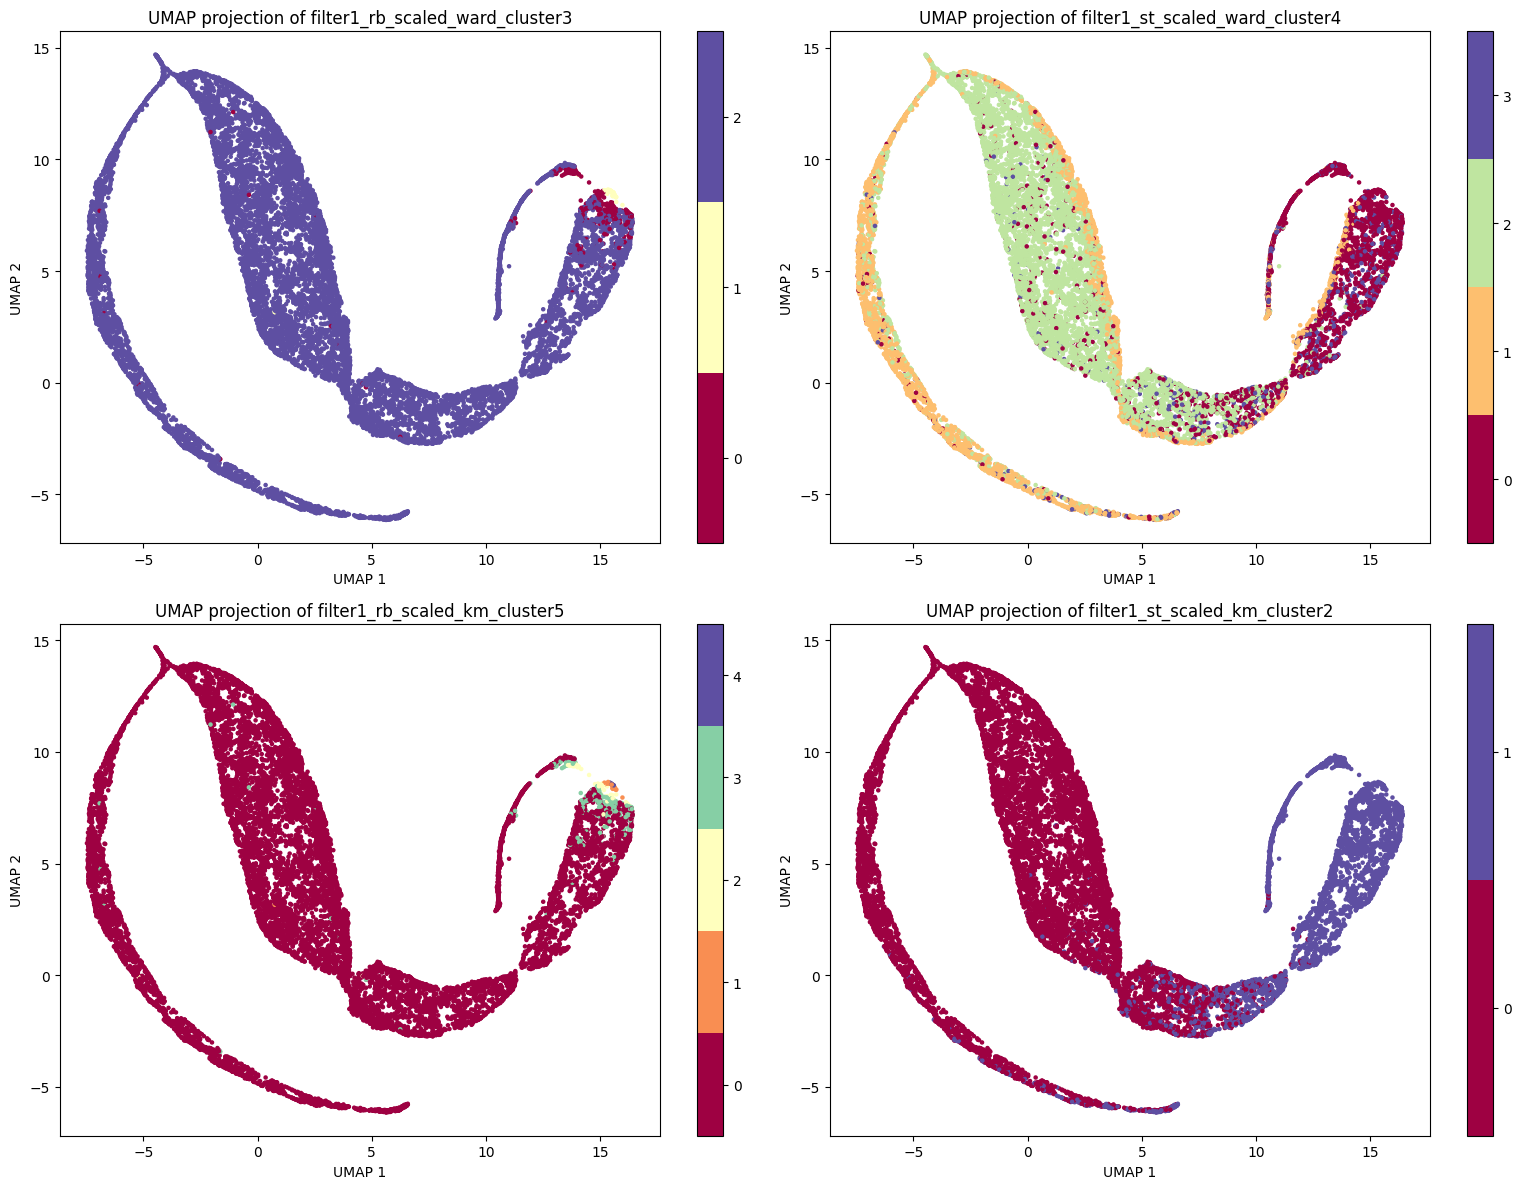

In [69]:
plot_umap_projections(people_filtered1, cluster_filter1)

In [70]:
groupby_mean(people_filtered1, 'filter1_st_scaled_km_cluster2')

filter1_st_scaled_km_cluster2,0,1
Income,37722.817552,37857.841793
Customer Lifetime Value,7958.440727,7852.041748
EnrollmentType,0.040777,0.153700
rejoined_program,0.000000,0.040797
Days_in_prog,1446.584291,352.451376
Cancelled_program,0.019431,0.212761
Enrollment_year,2017.527915,2020.292694
Enrollment_month,6.506842,6.864564
Location_cluster,2.441434,2.429791
TotalFlights,195.244527,62.671869


#### Cluster Extraction 2

In [72]:
# Filter the DataFrame based on cluster labels
loyal = people_filtered1[people_filtered1['filter1_st_scaled_km_cluster2'] == 0]

In [73]:
# List of cluster labels to exclude
exclude_clusters = [0]

# Filter the original dataset to exclude rows with specified cluster labels
people_filtered2 = people_filtered1[~people_filtered1['filter1_st_scaled_km_cluster2'].isin(exclude_clusters)]

In [74]:
people_filtered2 = people_filtered2.loc[:, ~people_filtered2.columns.str.startswith(("st_", "mm_", "rb_"))]

In [75]:
people_filtered2

,Income,Customer Lifetime Value,EnrollmentType,rejoined_program,Days_in_prog,Cancelled_program,Enrollment_year,Enrollment_month,Location_cluster,TotalFlights,...,Education_High School or Below,Education_Master,Marital_Divorced,Marital_Married,Marital_Single,filter1_rb_scaled_ward_cluster3,filter1_st_scaled_ward_cluster4,filter1_rb_scaled_km_cluster5,filter1_st_scaled_km_cluster2,filter1_st_scaled_km_cluster3
Loyalty#,,,,,,,,,,,,,,,,,,,,,
100504,59762.0,8807.61,0,0,243.0,1,2020,7,1,106.6,...,0,0,1,0,0,2,3,0,1,1
100590,51840.0,34090.04,1,0,297.0,0,2021,3,0,28.0,...,0,0,0,1,0,2,0,0,1,1
101547,0.0,5619.69,0,0,447.0,0,2020,10,1,58.0,...,0,0,0,1,0,2,1,0,1,1
101644,19683.0,8382.63,0,0,47.0,0,2021,11,1,6.0,...,0,1,0,1,0,0,0,2,1,1
101768,52423.0,13916.93,0,0,119.0,0,2021,9,2,6.0,...,0,0,0,0,1,0,0,2,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999758,0.0,18690.34,0,0,131.0,0,2021,8,2,16.0,...,0,0,0,0,1,0,0,3,1,1
999788,33397.0,8409.07,0,0,243.0,1,2020,2,1,79.8,...,0,0,0,1,0,2,3,0,1,1
999891,59732.0,3745.37,0,0,245.0,1,2019,5,3,1.9,...,0,0,0,1,0,0,3,3,1,1


### <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">(3) Third-Examination</h3>

#### Re-Scaling Data 2

In [ ]:
people_filtered1

,Income,Customer Lifetime Value,EnrollmentType,rejoined_program,Days_in_prog,Cancelled_program,Enrollment_year,Enrollment_month,Location_cluster,TotalFlights,...,Loyalty_Nova,Loyalty_Star,Education_Bachelor,Education_College,Education_Doctor,Education_High School or Below,Education_Master,Marital_Divorced,Marital_Married,Marital_Single
Loyalty#,,,,,,,,,,,,,,,,,,,,,
100018,82877.0,7919.20,0,0,874.0,0,2019,8,5,229.9,...,0,0,1,0,0,0,0,0,1,0
100102,0.0,2887.74,0,0,2122.0,0,2016,3,1,247.7,...,1,0,0,1,0,0,0,0,0,1
100140,0.0,2838.07,0,0,884.0,0,2019,7,5,216.8,...,1,0,0,1,0,0,0,1,0,0
100214,42837.0,4170.57,0,0,1242.0,0,2018,8,2,112.3,...,0,1,1,0,0,0,0,0,1,0
100272,80979.0,6622.05,0,0,1816.0,0,2017,1,1,186.4,...,0,1,1,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999891,59732.0,3745.37,0,0,245.0,1,2019,5,3,1.9,...,1,0,1,0,0,0,0,0,1,0
999902,0.0,7290.07,0,0,1681.0,0,2017,5,1,267.1,...,0,0,0,1,0,0,0,0,1,0
999940,21542.0,20266.50,0,0,523.0,0,2020,7,4,87.5,...,1,0,1,0,0,0,0,0,1,0


In [ ]:
people_filtered11 = people_filtered1.copy()

for column in people_filtered11.columns:
    if column.startswith('Total_Spend_Month_'):
        people_filtered11[column] = np.sqrt(people_filtered11[column])

In [ ]:
people_filtered1_st_scl = StandardScaler().fit_transform(people_filtered11)
people_filtered1_rb_scl = RobustScaler().fit_transform(people_filtered11)

#### Cluster Modelling 2

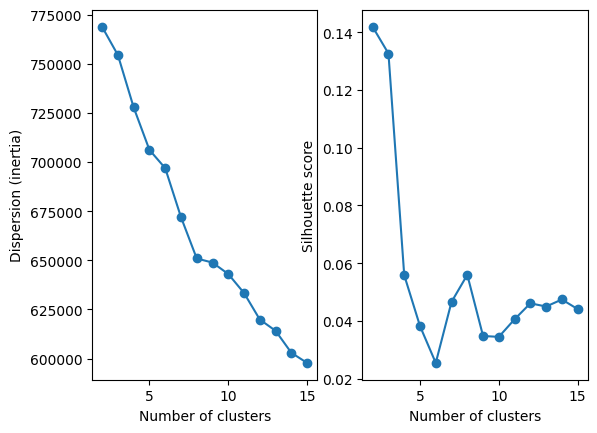

In [ ]:
plot_inertia_and_silhouette(people_filtered1_st_scl)

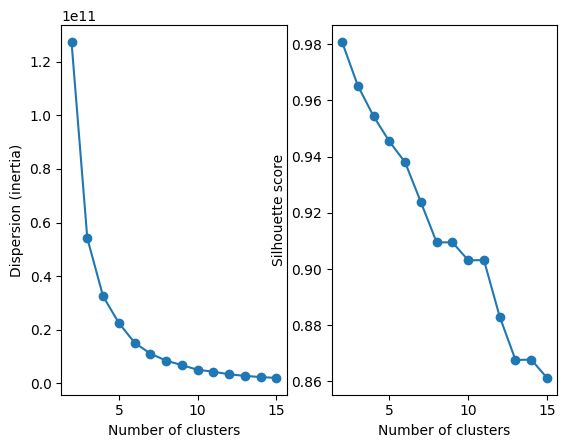

In [ ]:
plot_inertia_and_silhouette(people_filtered1_rb_scl)

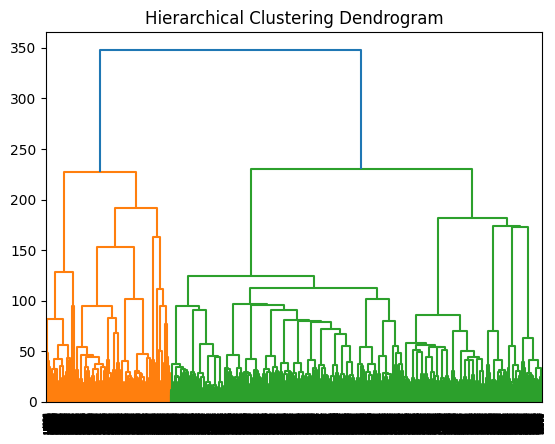

In [ ]:
plot_dendrogram(people_filtered1_st_scl, 'ward')

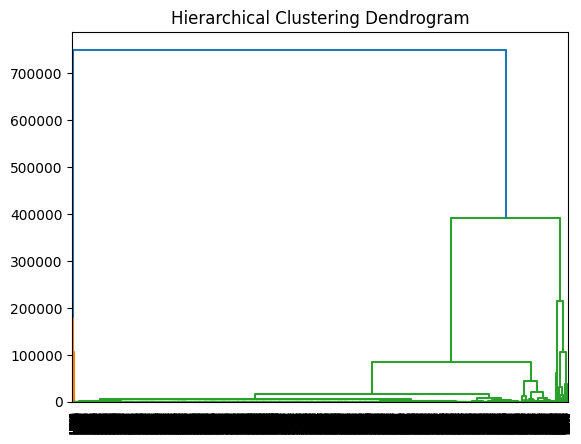

In [ ]:
plot_dendrogram(people_filtered1_rb_scl, 'ward')

#### Cluster Visualization 2

In [ ]:
people_filtered1['filter1_rb_scaled_ward_cluster3'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 3
    ).fit_predict(people_filtered1_rb_scl)

people_filtered1['filter1_st_scaled_ward_cluster4'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 4
    ).fit_predict(people_filtered1_st_scl)

In [ ]:
kmeans_rb_scl = KMeans(n_clusters=5, random_state=42).fit(people_filtered1_rb_scl)
people_filtered1['filter1_rb_scaled_km_cluster5'] = kmeans_rb_scl.predict(people_filtered1_rb_scl)

kmeans_st_scl = KMeans(n_clusters=2, random_state=42).fit(people_filtered1_st_scl)
people_filtered1['filter1_st_scaled_km_cluster2'] = kmeans_st_scl.predict(people_filtered1_st_scl)

In [ ]:
cluster_filter1 = ['filter1_rb_scaled_ward_cluster3', 'filter1_st_scaled_ward_cluster4', 'filter1_rb_scaled_km_cluster5', 'filter1_st_scaled_km_cluster2']

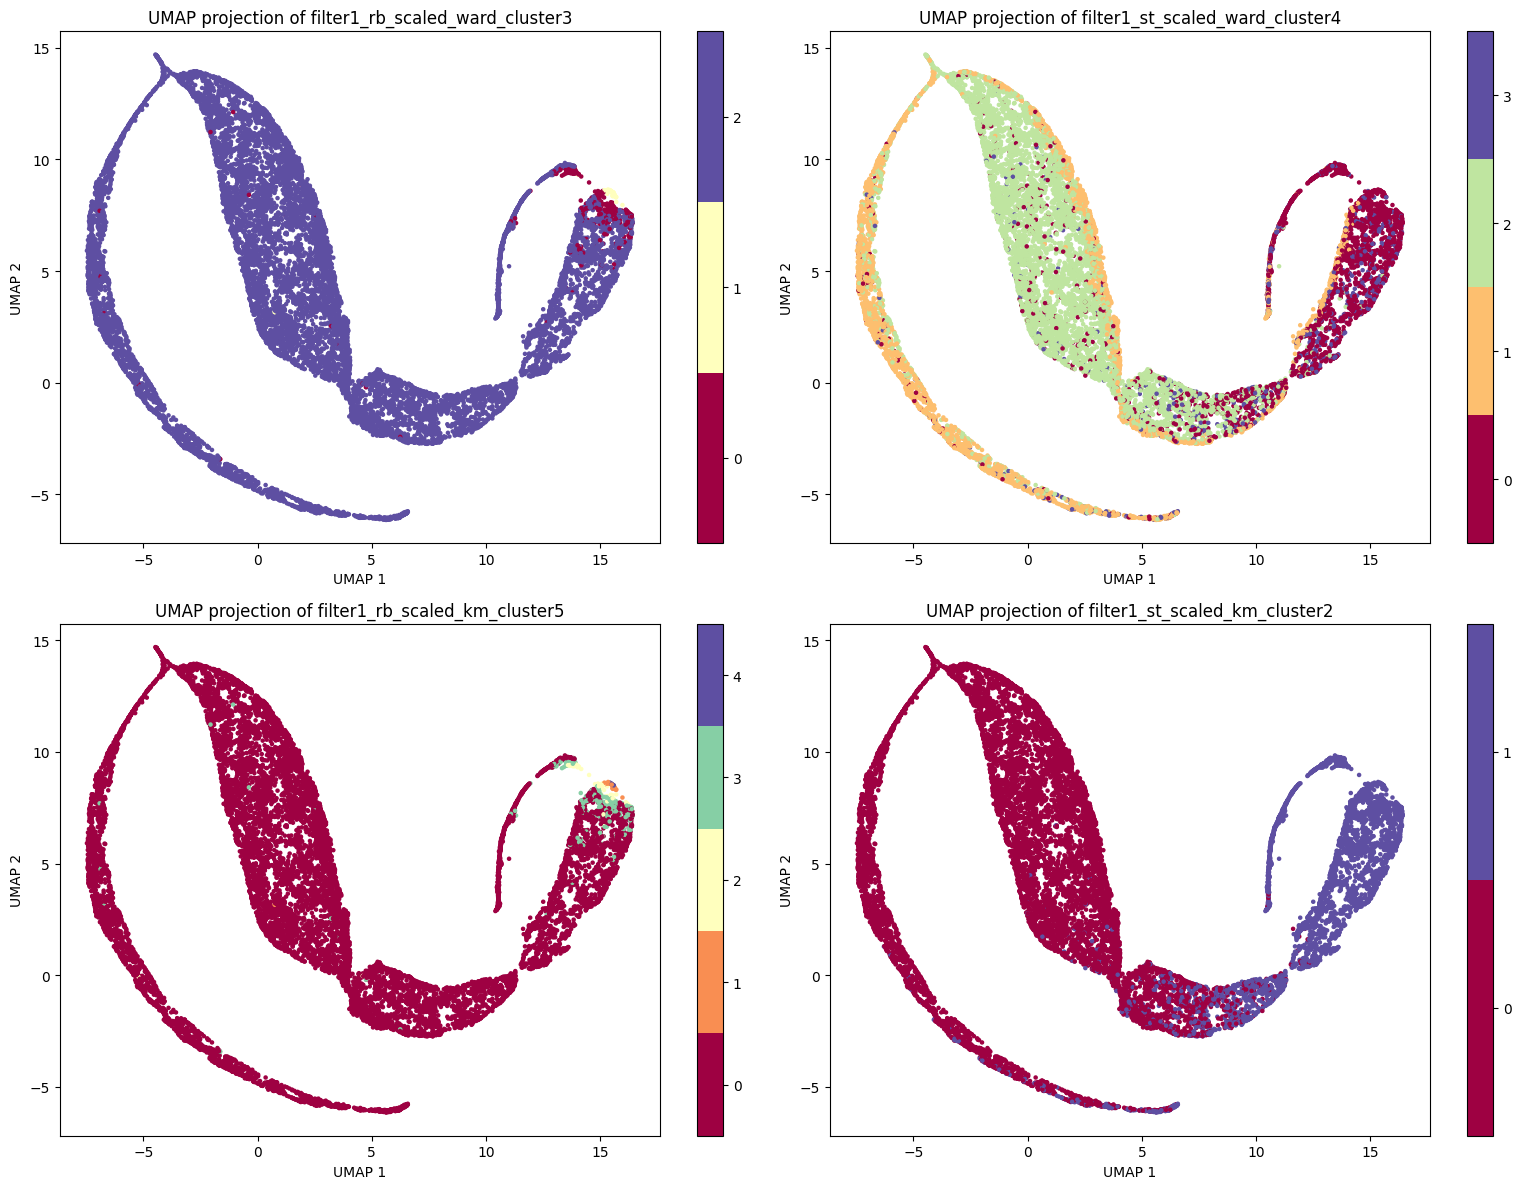

In [ ]:
plot_umap_projections(people_filtered1, cluster_filter1)

In [ ]:
groupby_mean(people_filtered1, 'filter1_st_scaled_km_cluster2')

filter1_st_scaled_km_cluster2,0,1
Income,37722.817552,37857.841793
Customer Lifetime Value,7958.440727,7852.041748
EnrollmentType,0.040777,0.153700
rejoined_program,0.000000,0.040797
Days_in_prog,1446.584291,352.451376
Cancelled_program,0.019431,0.212761
Enrollment_year,2017.527915,2020.292694
Enrollment_month,6.506842,6.864564
Location_cluster,2.441434,2.429791
TotalFlights,195.244527,62.671869


#### Cluster Extraction 2

In [ ]:
# Filter the DataFrame based on cluster labels
loyal = people_filtered1[people_filtered1['filter1_st_scaled_km_cluster2'] == 0]

In [ ]:
# List of cluster labels to exclude
exclude_clusters = [0]

# Filter the original dataset to exclude rows with specified cluster labels
people_filtered2 = people_filtered1[~people_filtered1['filter1_st_scaled_km_cluster2'].isin(exclude_clusters)]

In [ ]:
people_filtered2 = people_filtered2.loc[:, ~people_filtered2.columns.str.startswith(("st_", "mm_", "rb_"))]

In [ ]:
people_filtered2

,Income,Customer Lifetime Value,EnrollmentType,rejoined_program,Days_in_prog,Cancelled_program,Enrollment_year,Enrollment_month,Location_cluster,TotalFlights,...,Education_High School or Below,Education_Master,Marital_Divorced,Marital_Married,Marital_Single,filter1_rb_scaled_ward_cluster3,filter1_st_scaled_ward_cluster4,filter1_rb_scaled_km_cluster5,filter1_st_scaled_km_cluster2,filter1_st_scaled_km_cluster3
Loyalty#,,,,,,,,,,,,,,,,,,,,,
100504,59762.0,8807.61,0,0,243.0,1,2020,7,1,106.6,...,0,0,1,0,0,2,3,0,1,1
100590,51840.0,34090.04,1,0,297.0,0,2021,3,0,28.0,...,0,0,0,1,0,2,0,0,1,1
101547,0.0,5619.69,0,0,447.0,0,2020,10,1,58.0,...,0,0,0,1,0,2,1,0,1,1
101644,19683.0,8382.63,0,0,47.0,0,2021,11,1,6.0,...,0,1,0,1,0,0,0,2,1,1
101768,52423.0,13916.93,0,0,119.0,0,2021,9,2,6.0,...,0,0,0,0,1,0,0,2,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999758,0.0,18690.34,0,0,131.0,0,2021,8,2,16.0,...,0,0,0,0,1,0,0,3,1,1
999788,33397.0,8409.07,0,0,243.0,1,2020,2,1,79.8,...,0,0,0,1,0,2,3,0,1,1
999891,59732.0,3745.37,0,0,245.0,1,2019,5,3,1.9,...,0,0,0,1,0,0,3,3,1,1


# <span style="color:#0097b2">1. Cluster Extraction</span>
[Back to TOC](#toc)

In [ ]:
# Define file names for CSV files
file_names = ['veterinaries.csv', 'vegetarians.csv', 'gamers.csv', 'loyals.csv', 'alcoholics.csv', 'families.csv', 'young_adults.csv', 'karens.csv', 'promo_hunters.csv']

# Define dataframes and filenames
datasets = [veterinaries, vegetarians, gamers, loyals, alcoholics, families, young_adults, karens, promo_hunters]

# Save each subset as a CSV file
for df, file_name in zip(datasets, file_names):
    df.to_csv(file_name)